# Text Model — Lung Clinical Report Classifier

**Architecture:** Embedding → Positional Encoding → Bidirectional LSTM → Attention → FC  
**Dataset:** `lung_clinical_reports.csv` — 5,000 clinical observations, 5 classes  
**Classes:** Viral Pneumonia · COVID-19 Viral Pneumonia · Bacterial Pneumonia · Tuberculosis · Healthy

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
class Config:
    # Data
    CSV_PATH     = "/kaggle/input/datasets/souptik22fiitbs/final-dataset/respiratory_disease_harder_nan_target93_8900.csv"
    TEXT_COL     = "Clinical_Observation"
    LABEL_COL    = "Diagnosis_Label"
    MAX_LEN      = 128          # max tokens per report
    MIN_FREQ     = 2            # min word frequency for vocab
    TEST_SIZE    = 0.15
    VAL_SIZE     = 0.15

    # Model
    EMBED_DIM    = 256
    HIDDEN_DIM   = 256
    NUM_LAYERS   = 2
    OUTPUT_DIM   = 512
    DROPOUT      = 0.5

    # Training
    BATCH_SIZE   = 64
    EPOCHS       = 20
    LR           = 3e-4
    WEIGHT_DECAY = 1e-2
    CLIP_GRAD    = 1.0

cfg = Config()
print("Config loaded ✓")

Config loaded ✓


In [3]:
'''
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''

"\nimport os\n\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

In [4]:
# ─────────────────────────────────────────────────────────────
# 1. LOAD & INSPECT DATA
# ─────────────────────────────────────────────────────────────
df = pd.read_csv(cfg.CSV_PATH)

print(f"Dataset shape : {df.shape}")
print(f"\nLabel distribution:\n{df[cfg.LABEL_COL].value_counts()}")
print(f"\nSample record:")
print(df.iloc[0])

Dataset shape : (8900, 5)

Label distribution:
Diagnosis_Label
Corona Virus Disease    1780
Healthy                 1780
Tuberculosis            1780
Bacterial               1780
Viral Pneumonia         1780
Name: count, dtype: int64

Sample record:
Report_ID                                                       REP_00001
Patient_Age                                                            66
Patient_Sex                                                        Female
Clinical_Observation    Symptoms include reduced taste, headache, redu...
Diagnosis_Label                                      Corona Virus Disease
Name: 0, dtype: object


In [5]:
# ─────────────────────────────────────────────────────────────
# 2. LABEL ENCODING
# ─────────────────────────────────────────────────────────────
label_list  = sorted(df[cfg.LABEL_COL].unique())
label2idx   = {lbl: i for i, lbl in enumerate(label_list)}
idx2label   = {i: lbl for lbl, i in label2idx.items()}
NUM_CLASSES = len(label_list)

print(f"Classes ({NUM_CLASSES}):")
for i, lbl in idx2label.items():
    print(f"  {i}: {lbl}")

df["label"] = df[cfg.LABEL_COL].map(label2idx)

Classes (5):
  0: Bacterial
  1: Corona Virus Disease
  2: Healthy
  3: Tuberculosis
  4: Viral Pneumonia


In [6]:
# ─────────────────────────────────────────────────────────────
# 3. VOCABULARY & TOKENIZER
# ─────────────────────────────────────────────────────────────
import re

def simple_tokenize(text: str):
    """Lowercase, strip punctuation, split on whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

# Build vocabulary from training corpus only (after split)
# First split, then build vocab to avoid data leakage
train_df, test_df = train_test_split(
    df, test_size=cfg.TEST_SIZE, stratify=df["label"], random_state=SEED
)
train_df, val_df = train_test_split(
    train_df, test_size=cfg.VAL_SIZE / (1 - cfg.TEST_SIZE),
    stratify=train_df["label"], random_state=SEED
)

print(f"Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}")

# Count word frequencies in training set
counter = Counter()
for text in train_df[cfg.TEXT_COL]:
    counter.update(simple_tokenize(text))

# Build vocab: <PAD>=0, <UNK>=1
SPECIAL = ["<PAD>", "<UNK>"]
vocab_words = [w for w, c in counter.most_common() if c >= cfg.MIN_FREQ]
vocab = {w: i + len(SPECIAL) for i, w in enumerate(vocab_words)}
for i, tok in enumerate(SPECIAL):
    vocab[tok] = i

VOCAB_SIZE = len(vocab)
PAD_IDX    = vocab["<PAD>"]
UNK_IDX    = vocab["<UNK>"]
print(f"Vocabulary size : {VOCAB_SIZE:,}  (min_freq={cfg.MIN_FREQ})")


def encode(text: str, vocab: dict, max_len: int):
    """Tokenize, encode, pad/truncate to max_len. Returns (ids, mask)."""
    tokens = simple_tokenize(text)[: max_len]
    ids    = [vocab.get(t, UNK_IDX) for t in tokens]
    pad    = max_len - len(ids)
    mask   = [1] * len(ids) + [0] * pad
    ids    = ids + [PAD_IDX] * pad
    return ids, mask

Train : 6,230  |  Val : 1,335  |  Test : 1,335
Vocabulary size : 494  (min_freq=2)


In [7]:
# ─────────────────────────────────────────────────────────────
# 4. PYTORCH DATASET & DATALOADERS
# ─────────────────────────────────────────────────────────────
class ReportDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, vocab: dict, max_len: int):
        self.texts  = dataframe[cfg.TEXT_COL].tolist()
        self.labels = dataframe["label"].tolist()
        self.vocab  = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        ids, mask = encode(self.texts[idx], self.vocab, self.max_len)
        return (
            torch.tensor(ids,  dtype=torch.long),
            torch.tensor(mask, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )


train_ds = ReportDataset(train_df, vocab, cfg.MAX_LEN)
val_ds   = ReportDataset(val_df,   vocab, cfg.MAX_LEN)
test_ds  = ReportDataset(test_df,  vocab, cfg.MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches — Train: 98 | Val: 21 | Test: 21


In [8]:
# ─────────────────────────────────────────────────────────────
# 5. MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encodings added to token embeddings."""
    def __init__(self, embed_dim: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)


class AttentionMechanism(nn.Module):
    """Bahdanau-style additive attention over BiLSTM hidden states."""
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attention     = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.context_vector = nn.Linear(hidden_dim * 2, 1, bias=False)

    def forward(self, lstm_output: torch.Tensor, mask: torch.Tensor = None):
        energy       = torch.tanh(self.attention(lstm_output))      # (B, L, H*2)
        scores       = self.context_vector(energy).squeeze(-1)      # (B, L)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        attn_weights = F.softmax(scores, dim=1)                     # (B, L)
        context      = torch.bmm(
            attn_weights.unsqueeze(1), lstm_output
        ).squeeze(1)                                                 # (B, H*2)
        return context, attn_weights


class TextModel(nn.Module):
    """
    Token IDs → Embedding → Positional Encoding
             → BiLSTM → Attention → FC → feature vector

    When used standalone (num_classes > 0) adds a classification head.
    When used as encoder in a multimodal system, set num_classes=0 and
    use the returned feature vector for downstream fusion.
    """
    def __init__(
        self,
        vocab_size:  int   = 30522,
        embed_dim:   int   = 256,
        hidden_dim:  int   = 256,
        num_layers:  int   = 2,
        output_dim:  int   = 512,
        num_classes: int   = 5,
        max_len:     int   = 512,
        dropout:     float = 0.3,
        pad_idx:     int   = 0,
    ):
        super().__init__()
        self.embed_dim  = embed_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes

        self.embedding    = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len, dropout)
        self.bilstm       = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attention = AttentionMechanism(hidden_dim)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        # Classification head (standalone mode)
        if num_classes > 0:
            self.classifier = nn.Linear(output_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        for name, param in self.bilstm.named_parameters():
            if "weight" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor = None):
        """
        Args:
            input_ids      : (B, L) token IDs
            attention_mask : (B, L) 1=real token, 0=padding
        Returns:
            logits         : (B, num_classes)  if num_classes > 0
            features       : (B, output_dim)   feature vector
            attn_weights   : (B, L)
        """
        pad_mask = (attention_mask == 0) if attention_mask is not None else (input_ids == 0)

        x              = self.embedding(input_ids)          # (B, L, E)
        x              = self.pos_encoding(x)               # (B, L, E)
        lstm_out, _    = self.bilstm(x)                     # (B, L, H*2)
        context, attn  = self.attention(lstm_out, pad_mask) # (B, H*2), (B, L)
        features       = self.fc(context)                   # (B, output_dim)

        if self.num_classes > 0:
            logits = self.classifier(features)              # (B, C)
            return logits, features, attn
        return features, attn


# ── Instantiate ──────────────────────────────────────────────
model = TextModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = cfg.EMBED_DIM,
    hidden_dim  = cfg.HIDDEN_DIM,
    num_layers  = cfg.NUM_LAYERS,
    output_dim  = cfg.OUTPUT_DIM,
    num_classes = NUM_CLASSES,
    max_len     = cfg.MAX_LEN,
    dropout     = cfg.DROPOUT,
    pad_idx     = PAD_IDX,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 3,285,509
Trainable parameters : 3,285,509


In [9]:
# ─────────────────────────────────────────────────────────────
# 6. TRAINING & EVALUATION HELPERS
# ─────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = OneCycleLR(
    optimizer,
    max_lr      = cfg.LR,
    steps_per_epoch = len(train_loader),
    epochs      = cfg.EPOCHS,
    pct_start   = 0.1,
)


def run_epoch(loader, train=True):
    """One epoch of training or evaluation."""
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for input_ids, attn_mask, labels in loader:
            input_ids = input_ids.to(DEVICE)
            attn_mask = attn_mask.to(DEVICE)
            labels    = labels.to(DEVICE)

            logits, _, _ = model(input_ids, attn_mask)
            loss         = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), cfg.CLIP_GRAD)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total


print("Training helpers initialised ✓")

Training helpers initialised ✓


In [10]:
# ─────────────────────────────────────────────────────────────
# 7. TRAINING LOOP
# ─────────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_state = None

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 55)

for epoch in range(1, cfg.EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        flag = " ◀ best"

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {vl_loss:>8.4f}  {vl_acc:>7.4f}{flag}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# Restore best weights
model.load_state_dict(best_model_state)
print("Best model weights restored ✓")

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
-------------------------------------------------------
    1      1.6742     0.2011    1.5973   0.2554 ◀ best
    2      1.6185     0.2414    1.3973   0.3596 ◀ best
    3      1.3194     0.4507    1.0360   0.6449 ◀ best
    4      0.9878     0.6862    0.8035   0.7813 ◀ best
    5      0.8163     0.7862    0.7365   0.8022 ◀ best
    6      0.7555     0.8116    0.6817   0.8419 ◀ best
    7      0.6981     0.8432    0.6483   0.8494 ◀ best
    8      0.6812     0.8483    0.6543   0.8472
    9      0.6571     0.8629    0.6434   0.8532 ◀ best
   10      0.6439     0.8669    0.6201   0.8682 ◀ best
   11      0.6368     0.8698    0.6042   0.8816 ◀ best
   12      0.6183     0.8804    0.6285   0.8742
   13      0.6215     0.8735    0.5995   0.8757
   14      0.6104     0.8801    0.6054   0.8742
   15      0.6079     0.8791    0.5966   0.8719
   16      0.5996     0.8859    0.5998   0.8764
   17      0.6000     0.8823    0.5900   0.8794
   18     

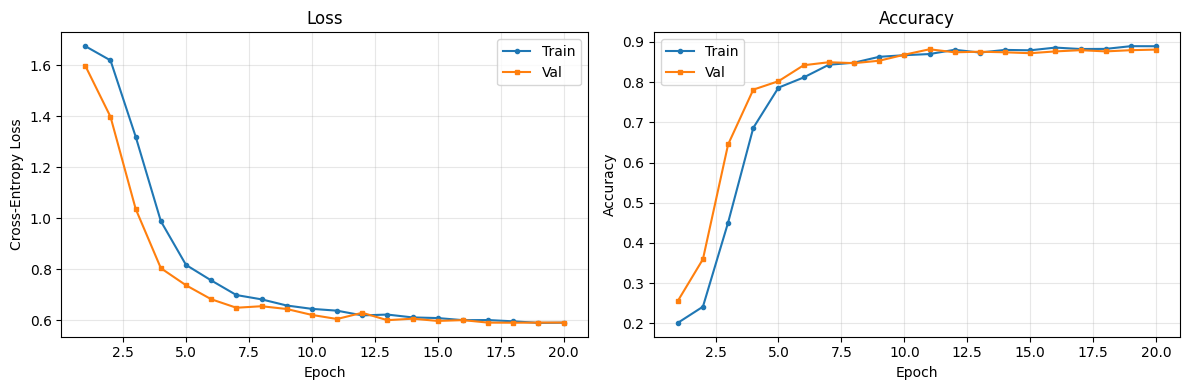

In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(epochs_range, history["val_loss"], label="Val", marker="s", markersize=3)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train", marker="o", markersize=3)
axes[1].plot(epochs_range, history["val_acc"], label="Val", marker="s", markersize=3)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────
# 9. TEST SET EVALUATION
# ─────────────────────────────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for input_ids, attn_mask, labels in test_loader:
        input_ids = input_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)
        logits, _, _ = model(input_ids, attn_mask)
        probs  = F.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test Accuracy : {test_acc:.4f}\n")

target_names = [idx2label[i] for i in range(NUM_CLASSES)]
print(classification_report(all_labels, all_preds, target_names=target_names))

Test Accuracy : 0.8689

                      precision    recall  f1-score   support

           Bacterial       0.95      0.85      0.90       267
Corona Virus Disease       0.70      0.93      0.80       267
             Healthy       1.00      0.80      0.89       267
        Tuberculosis       0.96      0.89      0.92       267
     Viral Pneumonia       0.84      0.88      0.86       267

            accuracy                           0.87      1335
           macro avg       0.89      0.87      0.87      1335
        weighted avg       0.89      0.87      0.87      1335



In [13]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import numpy as np

# Overall metrics
precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels, all_preds, average='weighted')
f1        = f1_score(all_labels, all_preds, average='weighted')

# Specificity calculation
cm = confusion_matrix(all_labels, all_preds)

specificities = []

for i in range(len(cm)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificities.append(specificity)

overall_specificity = np.mean(specificities)

print(f"Overall Precision   : {precision:.4f}")
print(f"Overall Recall      : {recall:.4f}")
print(f"Overall F1 Score    : {f1:.4f}")
print(f"Overall Specificity : {overall_specificity:.4f}")

Overall Precision   : 0.8881
Overall Recall      : 0.8689
Overall F1 Score    : 0.8723
Overall Specificity : 0.9672


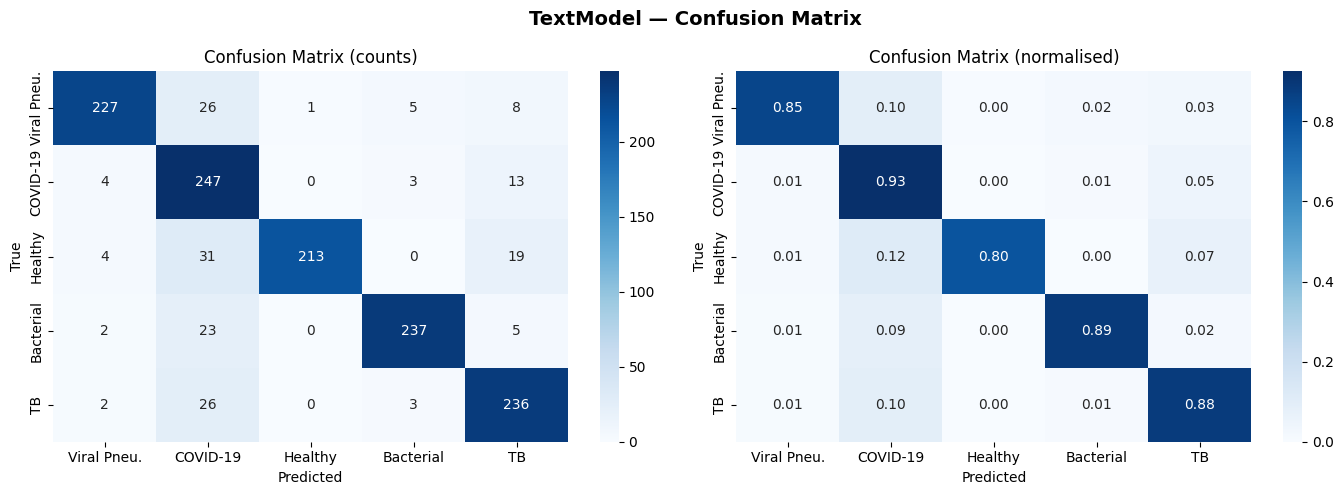

Plot saved → confusion_matrix.png


In [14]:
# ─────────────────────────────────────────────────────────────
# 10. CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
short_names = ["Viral Pneu.", "COVID-19", "Healthy", "Bacterial", "TB"]

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=short_names, yticklabels=short_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=short_names, yticklabels=short_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalised)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.suptitle("TextModel — Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → confusion_matrix.png")


────────────────────────────────────────────────────────────
True label : Bacterial
Report     : Trace pleural fluid is present. Bronchial wall thickening with patchy consolidation, may represent bacterial bronchopneu...


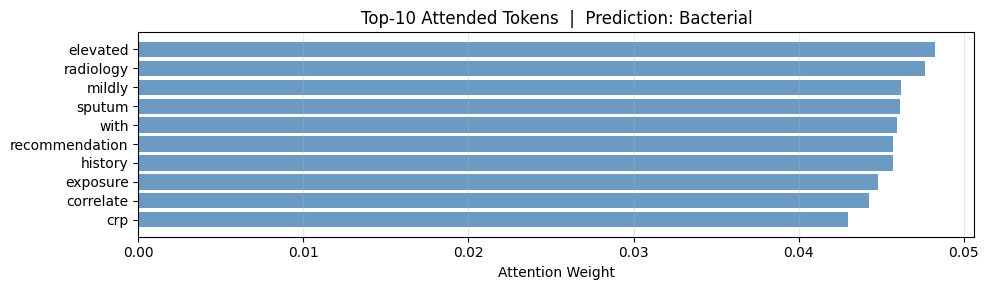

Predicted class : Bacterial

────────────────────────────────────────────────────────────
True label : Corona Virus Disease
Report     : Symptoms include reduced taste, headache, reduced smell. No pneumothorax. Multifocal subpleural ground-glass and reticul...


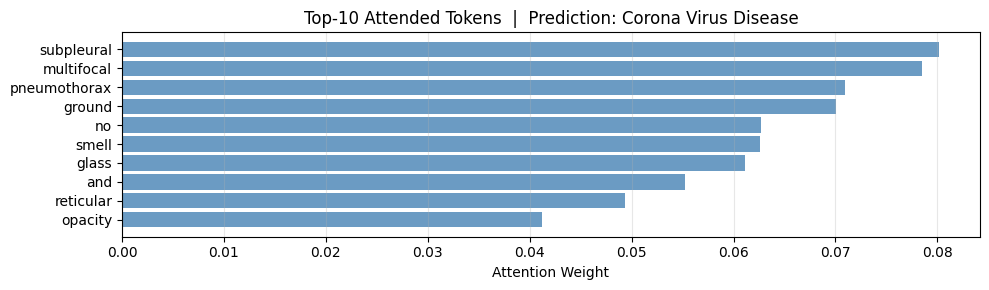

Predicted class : Corona Virus Disease

────────────────────────────────────────────────────────────
True label : Healthy
Report     : Clinical indicators show normal inflammatory markers. Patient reports no current cough, transient chest discomfort now r...


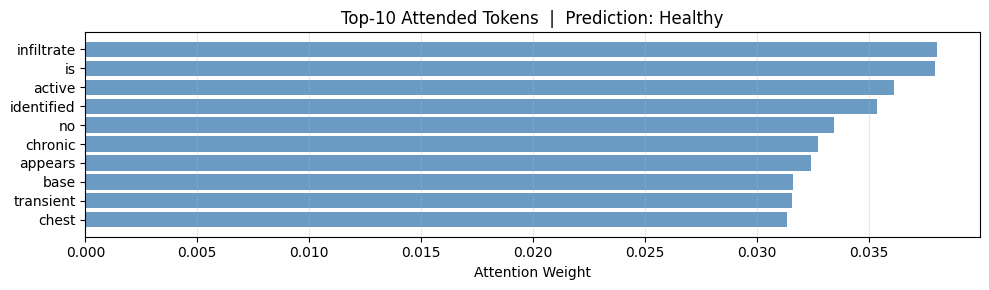

Predicted class : Healthy

────────────────────────────────────────────────────────────
True label : Tuberculosis
Report     : Upper-lobe predominant small nodules with subtle tree-in-bud branching in the left upper lobe. symptoms for 26 days, bor...


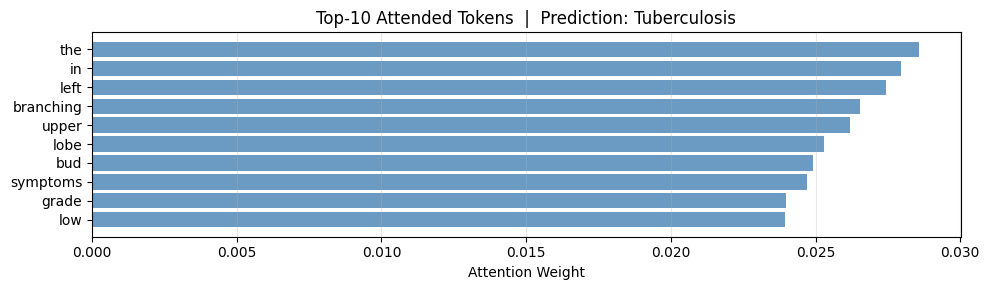

Predicted class : Tuberculosis

────────────────────────────────────────────────────────────
True label : Viral Pneumonia
Report     : Scattered centrilobular nodules and faint ground-glass opacities involving the right middle lobe. No pneumothorax. Clini...


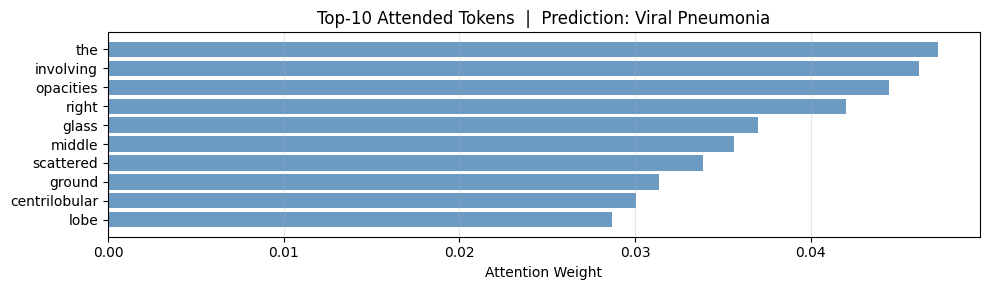

Predicted class : Viral Pneumonia


In [15]:
# ─────────────────────────────────────────────────────────────
# 11. ATTENTION WEIGHT VISUALISATION
# ─────────────────────────────────────────────────────────────
def visualise_attention(text: str, top_k: int = 15):
    """Plot the top-k attended tokens for a single report."""
    ids, mask = encode(text, vocab, cfg.MAX_LEN)
    input_ids = torch.tensor([ids],  dtype=torch.long).to(DEVICE)
    attn_mask = torch.tensor([mask], dtype=torch.long).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits, _, attn_weights = model(input_ids, attn_mask)
        pred_label = idx2label[logits.argmax(1).item()]

    # Map weights back to tokens
    tokens   = simple_tokenize(text)[: cfg.MAX_LEN]
    weights  = attn_weights[0, : len(tokens)].cpu().numpy()

    # Top-k tokens
    top_idx  = np.argsort(weights)[-top_k:][::-1]
    top_toks = [tokens[i] for i in top_idx]
    top_wts  = [weights[i] for i in top_idx]

    fig, ax = plt.subplots(figsize=(10, 3))
    bars = ax.barh(range(len(top_toks)), top_wts, color="steelblue", alpha=0.8)
    ax.set_yticks(range(len(top_toks)))
    ax.set_yticklabels(top_toks, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Attention Weight")
    ax.set_title(f"Top-{top_k} Attended Tokens  |  Prediction: {pred_label}", fontsize=12)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Predicted class : {pred_label}")
    return pred_label

# Pick one example from each class
for label_name in label_list:
    sample = df[df[cfg.LABEL_COL] == label_name].iloc[0][cfg.TEXT_COL]
    print(f"\n{'─'*60}")
    print(f"True label : {label_name}")
    print(f"Report     : {sample[:120]}...")
    visualise_attention(sample, top_k=10)

In [16]:
# ─────────────────────────────────────────────────────────────
# 12. INFERENCE FUNCTION
# ─────────────────────────────────────────────────────────────
def predict(text: str, return_probs: bool = False):
    """
    Predict the lung condition from a clinical report string.

    Args:
        text         : raw clinical observation text
        return_probs : if True, also return class probabilities dict
    Returns:
        predicted_label (str)
        [probabilities dict]  — if return_probs=True
    """
    ids, mask = encode(text, vocab, cfg.MAX_LEN)
    input_ids = torch.tensor([ids],  dtype=torch.long).to(DEVICE)
    attn_mask = torch.tensor([mask], dtype=torch.long).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits, _, _ = model(input_ids, attn_mask)
        probs = F.softmax(logits, dim=-1)[0].cpu().numpy()

    pred_label = idx2label[int(np.argmax(probs))]
    if return_probs:
        prob_dict = {idx2label[i]: float(p) for i, p in enumerate(probs)}
        return pred_label, prob_dict
    return pred_label


# ── Quick demo ────────────────────────────────────────────────
demo_texts = [
    "Bilateral ground-glass opacities with peripheral distribution. "
    "Patient tested PCR-positive for SARS-CoV-2. Oxygen saturation 91%.",

    "No consolidation or pleural effusion identified. "
    "Lung fields clear bilaterally. Normal chest radiograph.",

    "Cavitary lesion right upper lobe with surrounding consolidation. "
    "Acid-fast smear positive. Consistent with active tuberculosis.",
]

print("\n=== Inference Demo ===")
for txt in demo_texts:
    label, probs = predict(txt, return_probs=True)
    print(f"\nText   : {txt[:80]}...")
    print(f"Prediction : {label}")
    sorted_probs = sorted(probs.items(), key=lambda x: -x[1])
    for cls, p in sorted_probs:
        bar = "█" * int(p * 30)
        print(f"  {cls:<28} {bar:<30} {p:.3f}")


=== Inference Demo ===

Text   : Bilateral ground-glass opacities with peripheral distribution. Patient tested PC...
Prediction : Corona Virus Disease
  Corona Virus Disease         ███████████████████████████    0.905
  Viral Pneumonia              █                              0.036
  Bacterial                                                   0.024
  Tuberculosis                                                0.019
  Healthy                                                     0.015

Text   : No consolidation or pleural effusion identified. Lung fields clear bilaterally. ...
Prediction : Viral Pneumonia
  Viral Pneumonia              ██████████████████████         0.757
  Healthy                      ████                           0.140
  Corona Virus Disease         █                              0.040
  Bacterial                                                   0.033
  Tuberculosis                                                0.029

Text   : Cavitary lesion right upper lobe wi

In [17]:
# ─────────────────────────────────────────────────────────────
# 13. SAVE MODEL & VOCABULARY
# ─────────────────────────────────────────────────────────────
import pickle

checkpoint = {
    "model_state_dict" : model.state_dict(),
    "vocab"            : vocab,
    "label2idx"        : label2idx,
    "idx2label"        : idx2label,
    "config"           : {
        "vocab_size"  : VOCAB_SIZE,
        "embed_dim"   : cfg.EMBED_DIM,
        "hidden_dim"  : cfg.HIDDEN_DIM,
        "num_layers"  : cfg.NUM_LAYERS,
        "output_dim"  : cfg.OUTPUT_DIM,
        "num_classes" : NUM_CLASSES,
        "max_len"     : cfg.MAX_LEN,
        "dropout"     : cfg.DROPOUT,
        "pad_idx"     : PAD_IDX,
    },
    "best_val_acc"     : best_val_acc,
    "test_acc"         : test_acc,
}

torch.save(checkpoint, "text_model_trained.pt")
print(f"Model saved → text_model_trained.pt")
print(f"Best Val Acc : {best_val_acc:.4f}")
print(f"Test Acc     : {test_acc:.4f}")

Model saved → text_model_trained.pt
Best Val Acc : 0.8816
Test Acc     : 0.8689


In [18]:
# ─────────────────────────────────────────────────────────────
# 14. HOW TO LOAD & REUSE THE SAVED MODEL
# ─────────────────────────────────────────────────────────────

# ── Load ─────────────────────────────────────────────────────
ckpt = torch.load("text_model_trained.pt", map_location="cpu", weights_only=False)
cfg_ = ckpt["config"]

loaded_model = TextModel(**cfg_)
loaded_model.load_state_dict(ckpt["model_state_dict"])
loaded_model.eval()

loaded_vocab    = ckpt["vocab"]
loaded_idx2label = ckpt["idx2label"]

print("Model loaded successfully ✓")
print(f"Saved val accuracy : {ckpt['best_val_acc']:.4f}")
print(f"Saved test accuracy: {ckpt['test_acc']:.4f}")

Model loaded successfully ✓
Saved val accuracy : 0.8816
Saved test accuracy: 0.8689
